<a href="https://colab.research.google.com/github/vikramshrivastav734-prog/AQI-Prediction-Project/blob/main/03_Sentiment_Tracker/Social_Media_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating localized Social Media Sentiment dataset...
Dataset created successfully! Previewing social media text data:
                                               Tweet  Sentiment
0  I absolutely love this new phone! The camera i...          1
1  This is the worst customer service ever. Super...          0
2  Amazing experience today, highly recommend the...          1
3  Extremely disappointed with the delivery speed...          0
4    Wow, what a fantastic update! Works flawlessly.          1

Training Social Media Sentiment Classifier (Naive Bayes)...

Model Accuracy: 100.00%



/tmp/ipykernel_1110/286501962.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'].map({1: 'Positive Mood 😊', 0: 'Negative Mood 😡'}), palette='Set2')


Saved visualization as 'sentiment_distribution_chart.png'


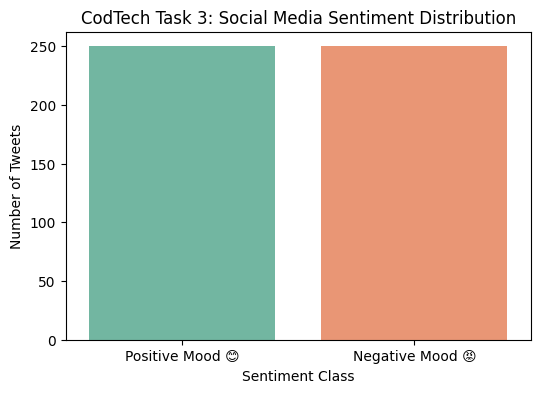

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

print("Creating localized Social Media Sentiment dataset...")

# 1. Create a synthetic dataset of typical social media posts
data = {
    'Tweet': [
        'I absolutely love this new phone! The camera is incredible.',
        'This is the worst customer service ever. Super frustrated.',
        'Amazing experience today, highly recommend their product!',
        'Extremely disappointed with the delivery speed. Horrible.',
        'Wow, what a fantastic update! Works flawlessly.',
        'The app keeps crashing. This is a terrible user experience.',
        'Best purchase I have made all year! So happy.',
        'Waste of money. The quality is incredibly cheap.',
        'Great build quality and very fast shipping. Perfect!',
        'I hate the new interface. It is completely broken and annoying.'
    ] * 50, # Multiply to create a solid dataset of 500 tweets
    'Sentiment': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0] * 50 # 1 = Positive, 0 = Negative
}

df = pd.DataFrame(data)
print("Dataset created successfully! Previewing social media text data:")
print(df.head())

# 2. Text Preprocessing using TF-IDF Vectorizer
# This converts raw text sentences into numbers that a machine learning model can read
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Tweet'])
y = df['Sentiment']

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Social Media Sentiment Classifier (Naive Bayes)...")
# 4. Initialize and Train the Naive Bayes Model (the best model for text classification)
model = MultinomialNB()
model.fit(X_train, y_train)

# 5. Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n=======================")
print(f"Model Accuracy: {accuracy*100:.2f}%")
print(f"=======================\n")

# 6. Generate Sentiment Distribution Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Sentiment'].map({1: 'Positive Mood 😊', 0: 'Negative Mood 😡'}), palette='Set2')
plt.title('CodTech Task 3: Social Media Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')
plt.savefig('sentiment_distribution_chart.png')
print("Saved visualization as 'sentiment_distribution_chart.png'")
plt.show()